In [59]:
import pandas as pd
import numpy as np

# Path to the CSV file
file_path = 'https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/scaleups_count.csv'
file_path2 = 'https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/investors_count.csv'
file_path3 = 'https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/inc_acc_count.csv'
file_path4 = 'https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/universities_count.csv'
# Load the CSV into a DataFrame
df = pd.read_csv(file_path)
df2 = pd.read_csv(file_path2)
df3 = pd.read_csv(file_path3)
df4 = pd.read_csv(file_path4)

df = df[['FUA','Count']]
df2 = df2[['FUA','Count']]
df3 = df3[['FUA','Count']]
df4 = df4[['FUA','Count']]
df

,FUA,Count
0,Paris,86
1,Berlin,50
2,Stockholm,46
3,Amsterdam,44
4,Munich,38
...,...,...
82,Bucharest,1
83,Bonn,1
84,Southampton,1
85,Karlsruhe,1


<ipython-input-60-3b9c9467a181>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaleups_df.rename(columns={'Count': 'Scaleups_Count'}, inplace=True)
<ipython-input-60-3b9c9467a181>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  investors_df.rename(columns={'Count': 'Investors_Count'}, inplace=True)
<ipython-input-60-3b9c9467a181>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  incubators_df.rename(columns={'Count': 'Incubators_

          FUA  Scaleups_Count  Investors_Count  Incubators_Count  \
0      Aachen            11.0             17.0               0.0   
1     Aalborg             4.0              2.0               0.0   
2      Aarhus             7.0              7.0               0.0   
3   Amsterdam            44.0             90.0               3.0   
4     Antwerp             7.0              5.0               0.0   
..        ...             ...              ...               ...   
86     Vienna            12.0             15.0               4.0   
87    Vilnius             3.0             10.0               2.0   
88     Warsaw             6.0             25.0               1.0   
89    Wroclaw             2.0              2.0               1.0   
90     Zagreb             2.0              1.0               0.0   

    Universities_Count  Cluster              Cluster Label  Total_Score  
0                  2.0        4  Top Emerging Scaleup City     0.427326  
1                  1.0        0    

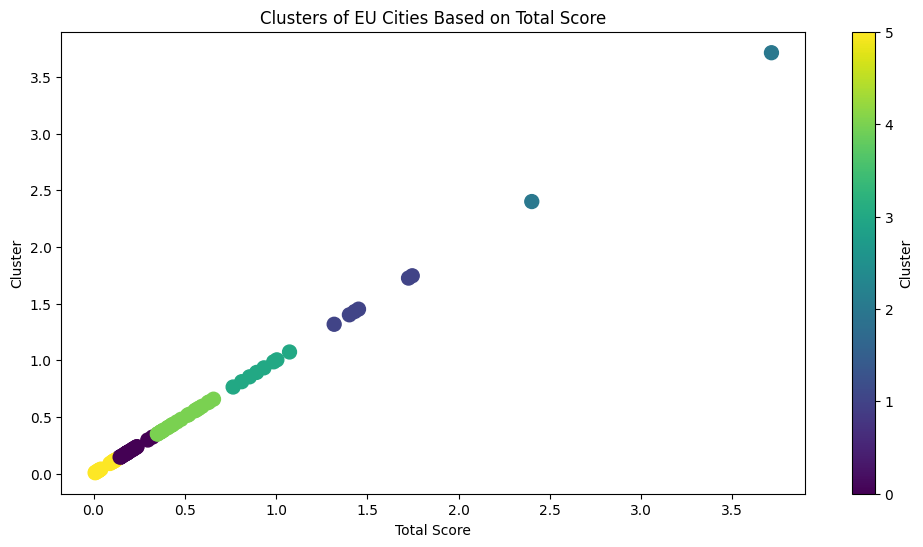

In [60]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Example DataFrames (replace these with your actual data)
scaleups_df = df
investors_df = df2
incubators_df = df3
universities_df = df4

# Rename "Count" column in each dataframe
scaleups_df.rename(columns={'Count': 'Scaleups_Count'}, inplace=True)
investors_df.rename(columns={'Count': 'Investors_Count'}, inplace=True)
incubators_df.rename(columns={'Count': 'Incubators_Count'}, inplace=True)
universities_df.rename(columns={'Count': 'Universities_Count'}, inplace=True)

# Merge DataFrames on FUA column
merged_df = scaleups_df.merge(investors_df, on='FUA', how='outer') \
                       .merge(incubators_df, on='FUA', how='outer') \
                       .merge(universities_df, on='FUA', how='outer')

# Fill missing values with 0
merged_df.fillna(0, inplace=True)

# Normalize the data (excluding the FUA column)
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(merged_df[['Scaleups_Count', 'Investors_Count', 'Incubators_Count', 'Universities_Count']])
normalized_df = pd.DataFrame(normalized_data, columns=['Scaleups_Score', 'Investors_Score', 'Incubators_Score', 'Universities_Score'])

# Create a new DataFrame combining the FUA and normalized scores
df5 = pd.concat([merged_df[['FUA']], normalized_df], axis=1)
df5['Total_Score'] = df5[['Scaleups_Score', 'Investors_Score', 'Incubators_Score', 'Universities_Score']].sum(axis=1)

# Perform K-means clustering based on the Total_Score
kmeans = KMeans(n_clusters=6, random_state=42)
df5['Cluster'] = kmeans.fit_predict(df5[['Total_Score']])

# Define cluster labels (based on your categories)
cluster_labels = {
    0: 'Emerging Scaleup City',
    1: 'Top European Scaleup City',
    2: 'Global Scaleup City',
    3: 'European Scaleup City',
    4: 'Top Emerging Scaleup City',
    5: 'Regional Scaleup City'
}
df5['Cluster Label'] = df5['Cluster'].map(cluster_labels)

# Merge the clusters back to the original merged DataFrame
merged_df = merged_df.merge(df5[['FUA', 'Cluster', 'Cluster Label','Total_Score']], on='FUA', how='left')

# Save or display the result
print(merged_df)

# Visualize clusters (optional)
plt.figure(figsize=(12, 6))
plt.scatter(df5['Total_Score'], df5['Total_Score'], c=df5['Cluster'], cmap='viridis', s=100)
plt.title('Clusters of EU Cities Based on Total Score')
plt.xlabel('Total Score')
plt.ylabel('Cluster')
plt.colorbar(label='Cluster')
plt.show()


In [61]:
merged_df

,FUA,Scaleups_Count,Investors_Count,Incubators_Count,Universities_Count,Cluster,Cluster Label,Total_Score
0,Aachen,11.0,17.0,0.0,2.0,4,Top Emerging Scaleup City,0.427326
1,Aalborg,4.0,2.0,0.0,1.0,0,Emerging Scaleup City,0.177326
2,Aarhus,7.0,7.0,0.0,1.0,0,Emerging Scaleup City,0.226744
3,Amsterdam,44.0,90.0,3.0,2.0,1,Top European Scaleup City,1.451827
4,Antwerp,7.0,5.0,0.0,1.0,0,Emerging Scaleup City,0.220930
...,...,...,...,...,...,...,...,...
86,Vienna,12.0,15.0,4.0,2.0,3,European Scaleup City,1.004568
87,Vilnius,3.0,10.0,2.0,0.0,4,Top Emerging Scaleup City,0.349668
88,Warsaw,6.0,25.0,1.0,1.0,4,Top Emerging Scaleup City,0.410299
89,Wroclaw,2.0,2.0,1.0,0.0,0,Emerging Scaleup City,0.171927


In [62]:
output_file = 'clusters.csv'
merged_df.to_csv(output_file, index=False)